# 06 - Demo Coordinate Forecast

Runs one month-ahead environmental proxy-risk inference for a single coordinate inside the Sagil study area. This notebook does not train or refit models; it loads artifacts created by notebooks 03, 04, and 05.


## 1. Configure Demo Coordinate
Defines the coordinate, source month, history window, and whether to use an existing raw monthly CSV for offline testing or call Earth Engine for a live extraction.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "config" / "project_config.yaml"
OUTPUT_CSV = PROJECT_ROOT / "reports" / "demo_coordinate_prediction.csv"

DEMO_LATITUDE = 2.32289114
DEMO_LONGITUDE = 102.6465942
DEMO_SAMPLE_ID = "demo_sagil_1"
SOURCE_MONTH = "2026-05-01"
HISTORY_MONTHS = 13

USE_EXISTING_RAW_CSV = True
RAW_CSV = PROJECT_ROOT / "data" / "raw" / "monthly" / "sagil_1.csv"
ALLOW_INCOMPLETE_SOURCE_MONTH = False


## 2. Run Month+1 Prediction
Loads trained artifacts, prepares the recent monthly history for the demo coordinate, and writes `reports/demo_coordinate_prediction.csv`. Set `USE_EXISTING_RAW_CSV = False` to download the recent GEE rows for the coordinate.


In [2]:
import pandas as pd

from src.demo_inference import DemoCoordinateConfig, predict_demo_coordinate

raw_csv = RAW_CSV if USE_EXISTING_RAW_CSV else None
prediction = predict_demo_coordinate(DemoCoordinateConfig(
    latitude=DEMO_LATITUDE,
    longitude=DEMO_LONGITUDE,
    sample_id=DEMO_SAMPLE_ID,
    source_month=SOURCE_MONTH,
    history_months=HISTORY_MONTHS,
    allow_incomplete_source_month=ALLOW_INCOMPLETE_SOURCE_MONTH,
    output_csv=OUTPUT_CSV,
    config_path=CONFIG_PATH,
    raw_csv=raw_csv,
))

display(prediction)


,sample_id,latitude,longitude,source_month,target_month,history_start_month,history_end_month,history_month_count,source_month_status,persistence_predicted_proxy_score,ridge_predicted_proxy_score,random_forest_predicted_proxy_score,sequence_model_predicted_proxy_score,lstm_predicted_proxy_score,transformer_predicted_proxy_score,best_model,best_model_predicted_proxy_score,predicted_direction,predicted_severity
0,demo_sagil_1,2.322891,102.646594,2026-05-01,2026-06-01,2025-05-01,2026-05-01,13,requested_source_month,0.079769,-0.036328,0.09047,-0.038161,-0.038161,-0.120304,transformer,-0.120304,drought,low


## 3. Visualize Demo Prediction
Compares available per-model predictions for the same source month and highlights the best-model output selected by `artifacts/model_registry.json`.


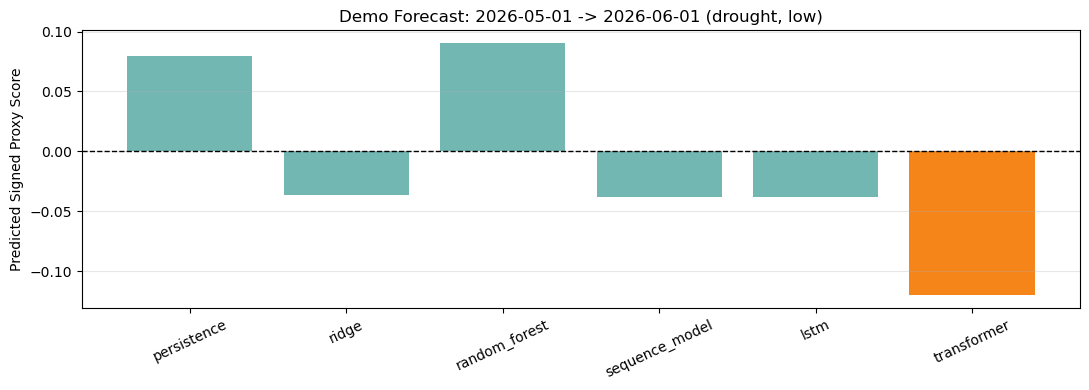

In [3]:
import matplotlib.pyplot as plt


def plot_demo_prediction(prediction):
    if prediction.empty:
        print("No demo prediction available for plotting.")
        return
    prediction_columns = [
        "persistence_predicted_proxy_score",
        "ridge_predicted_proxy_score",
        "random_forest_predicted_proxy_score",
        "sequence_model_predicted_proxy_score",
        "lstm_predicted_proxy_score",
        "transformer_predicted_proxy_score",
    ]
    available = [column for column in prediction_columns if column in prediction.columns and prediction[column].notna().any()]
    if not available:
        print("No model prediction columns available for plotting.")
        return
    values = prediction.loc[0, available].astype(float)
    labels = [column.replace("_predicted_proxy_score", "") for column in available]
    best_model = prediction.loc[0, "best_model"]

    fig, axis = plt.subplots(figsize=(11, 4))
    colors = ["#F58518" if label == best_model else "#72B7B2" for label in labels]
    axis.bar(labels, values, color=colors)
    axis.axhline(0, linestyle="--", color="black", linewidth=1)
    axis.set_title(
        f"Demo Forecast: {prediction.loc[0, 'source_month']} -> {prediction.loc[0, 'target_month']} "
        f"({prediction.loc[0, 'predicted_direction']}, {prediction.loc[0, 'predicted_severity']})"
    )
    axis.set_ylabel("Predicted Signed Proxy Score")
    axis.tick_params(axis="x", rotation=25)
    axis.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()


plot_demo_prediction(prediction)


## 4. Output Check
Reloads the saved CSV so the file written to `reports/` is easy to inspect after the notebook run.


In [4]:
saved_prediction = pd.read_csv(OUTPUT_CSV)
display(saved_prediction)


,sample_id,latitude,longitude,source_month,target_month,history_start_month,history_end_month,history_month_count,source_month_status,persistence_predicted_proxy_score,ridge_predicted_proxy_score,random_forest_predicted_proxy_score,sequence_model_predicted_proxy_score,lstm_predicted_proxy_score,transformer_predicted_proxy_score,best_model,best_model_predicted_proxy_score,predicted_direction,predicted_severity
0,demo_sagil_1,2.322891,102.646594,2026-05-01,2026-06-01,2025-05-01,2026-05-01,13,requested_source_month,0.079769,-0.036328,0.09047,-0.038161,-0.038161,-0.120304,transformer,-0.120304,drought,low
